# HOG + SVM 行人检测实验
## 数据集：PennFudanPed（170 张图，含标注框）
### 流程：正样本提取 → 负样本裁取 → HOG 特征 → SVM 训练 → 滑动窗口检测 → NMS → 可视化

In [2]:
import cv2
import numpy as np
import os
import re
import random
import joblib
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# ── matplotlib 中文字体配置 ──────────────────────────────
matplotlib.rcParams['font.family'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False   # 负号正常显示

random.seed(42)
np.random.seed(42)

# ── 路径配置 ──────────────────────────────────────────────
BASE_DIR   = Path("PennFudanPed")
IMG_DIR    = BASE_DIR / "PNGImages"
ANN_DIR    = BASE_DIR / "Annotation"

WIN_W, WIN_H = 64, 128          # HOG 标准行人窗口（宽×高）
NEG_PER_IMG  = 10               # 每张图最多裁取的负样本数
MAX_NEG_RATIO = 1.2             # 负样本上限 = 正样本数 × 该比例

print("路径检查：")
print(f"  图像目录存在：{IMG_DIR.exists()}, 标注目录存在：{ANN_DIR.exists()}")

路径检查：
  图像目录存在：True, 标注目录存在：True


## 第一步：解析标注文件，提取正样本（行人裁剪块）

In [3]:
def parse_annotation(ann_path):
    """解析 PennFudanPed 标注文件，返回 [(xmin,ymin,xmax,ymax), ...] 列表"""
    boxes = []
    pattern = re.compile(
        r'Bounding box for object \d+.*?:\s*\((\d+),\s*(\d+)\)\s*-\s*\((\d+),\s*(\d+)\)'
    )
    with open(ann_path, 'r') as f:
        for line in f:
            m = pattern.search(line)
            if m:
                x1, y1, x2, y2 = int(m.group(1)), int(m.group(2)), int(m.group(3)), int(m.group(4))
                boxes.append((x1, y1, x2, y2))
    return boxes


def extract_positive_samples(img_dir, ann_dir, win_w, win_h, min_box_size=32):
    """
    从每张图的标注框中裁剪行人区域，resize 到 win_w×win_h 作为正样本。
    返回：patches (list of ndarray HxWx3), ann_map (dict: img_path -> [boxes])
    """
    patches = []
    ann_map = {}
    ann_files = sorted(ann_dir.glob("*.txt"))

    for ann_file in ann_files:
        img_file = img_dir / (ann_file.stem + ".png")
        if not img_file.exists():
            continue
        img = cv2.imread(str(img_file))
        if img is None:
            continue
        boxes = parse_annotation(ann_file)
        ann_map[str(img_file)] = boxes
        for (x1, y1, x2, y2) in boxes:
            bw, bh = x2 - x1, y2 - y1
            if bw < min_box_size or bh < min_box_size:
                continue
            crop = img[y1:y2, x1:x2]
            crop = cv2.resize(crop, (win_w, win_h))
            patches.append(crop)

    print(f"正样本数量：{len(patches)}  （来自 {len(ann_map)} 张图）")
    return patches, ann_map


pos_patches, annotation_map = extract_positive_samples(IMG_DIR, ANN_DIR, WIN_W, WIN_H)

正样本数量：407  （来自 170 张图）


## 第二步：从同一批图像中裁取背景块作为负样本

In [4]:
def iou(boxA, boxB):
    """计算两个框的 IoU（用于判断负样本是否与行人框重叠）"""
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    inter = max(0, xB - xA) * max(0, yB - yA)
    if inter == 0:
        return 0.0
    areaA = (boxA[2]-boxA[0]) * (boxA[3]-boxA[1])
    areaB = (boxB[2]-boxB[0]) * (boxB[3]-boxB[1])
    return inter / float(areaA + areaB - inter)


def extract_negative_samples(ann_map, win_w, win_h, neg_per_img, max_total, iou_thresh=0.15):
    """
    对每张图随机裁取 neg_per_img 个与所有行人框 IoU < iou_thresh 的背景块。
    总数不超过 max_total。
    """
    patches = []
    for img_path, gt_boxes in ann_map.items():
        if len(patches) >= max_total:
            break
        img = cv2.imread(img_path)
        if img is None:
            continue
        H, W = img.shape[:2]
        attempts, collected = 0, 0
        while collected < neg_per_img and attempts < 200:
            attempts += 1
            # 随机宽高（与行人尺寸相近的比例）
            scale = random.uniform(0.5, 1.5)
            nw = int(win_w * scale)
            nh = int(win_h * scale)
            if nw > W or nh > H:
                continue
            x1 = random.randint(0, W - nw)
            y1 = random.randint(0, H - nh)
            x2, y2 = x1 + nw, y1 + nh
            cand = (x1, y1, x2, y2)
            # 检查与所有 GT 框的重叠
            if any(iou(cand, gb) > iou_thresh for gb in gt_boxes):
                continue
            crop = img[y1:y2, x1:x2]
            crop = cv2.resize(crop, (win_w, win_h))
            patches.append(crop)
            collected += 1
        if len(patches) >= max_total:
            patches = patches[:max_total]
            break

    print(f"负样本数量：{len(patches)}")
    return patches


max_neg = int(len(pos_patches) * MAX_NEG_RATIO)
neg_patches = extract_negative_samples(annotation_map, WIN_W, WIN_H, NEG_PER_IMG, max_neg)

print(f"\n正样本：{len(pos_patches)}  负样本：{len(neg_patches)}"
      f"  比例：1 : {len(neg_patches)/len(pos_patches):.2f}")

负样本数量：488

正样本：407  负样本：488  比例：1 : 1.20


## 第三步：可视化样本示例

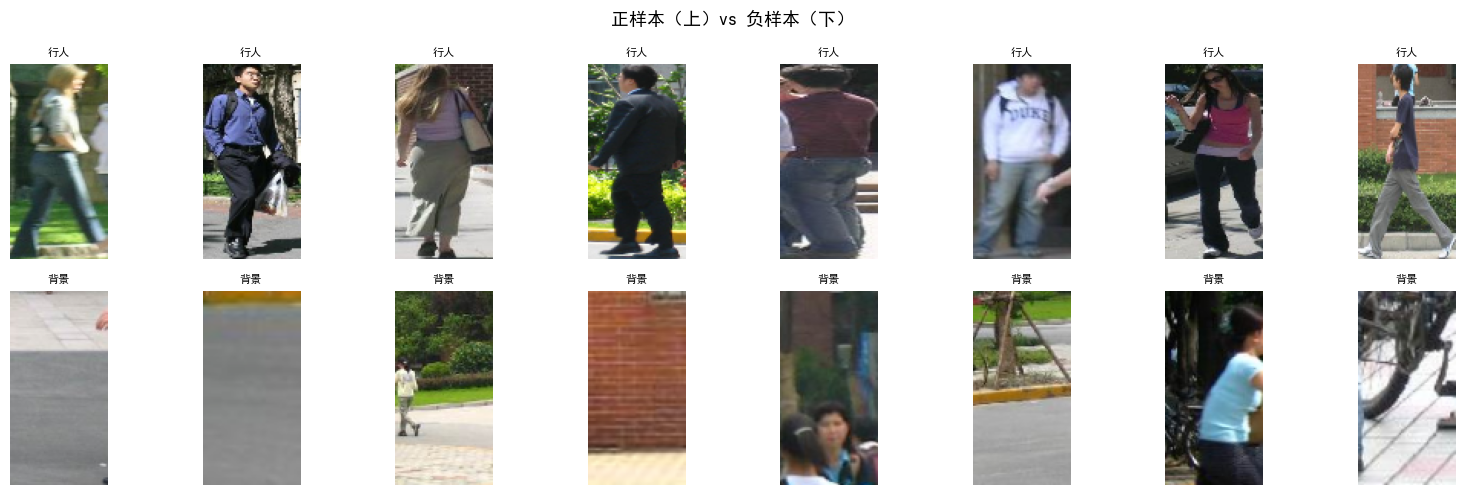

In [5]:
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle("正样本（上）vs 负样本（下）", fontsize=13)

for i, ax in enumerate(axes[0]):
    idx = random.randint(0, len(pos_patches)-1)
    ax.imshow(cv2.cvtColor(pos_patches[idx], cv2.COLOR_BGR2RGB))
    ax.set_title("行人", fontsize=8)
    ax.axis('off')

for i, ax in enumerate(axes[1]):
    idx = random.randint(0, len(neg_patches)-1)
    ax.imshow(cv2.cvtColor(neg_patches[idx], cv2.COLOR_BGR2RGB))
    ax.set_title("背景", fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.savefig("sample_preview.png", dpi=100, bbox_inches='tight')
plt.show()

## 第四步：提取 HOG 特征

In [6]:
# OpenCV HOGDescriptor 配置（Dalal & Triggs 2005 经典参数）
hog = cv2.HOGDescriptor(
    _winSize   = (WIN_W, WIN_H),      # 检测窗口 64×128
    _blockSize = (16, 16),            # 块大小
    _blockStride = (8, 8),            # 块步长
    _cellSize  = (8, 8),              # 单元格大小
    _nbins     = 9                    # 梯度方向 bins
)

def compute_hog_batch(patches, hog_desc):
    """对一批图像块批量提取 HOG 特征，返回 (N, D) ndarray"""
    feats = []
    for p in patches:
        gray = cv2.cvtColor(p, cv2.COLOR_BGR2GRAY)
        feat = hog_desc.compute(gray)          # shape (D, 1)
        feats.append(feat.flatten())
    return np.array(feats, dtype=np.float32)


print("提取正样本 HOG 特征...")
X_pos = compute_hog_batch(pos_patches, hog)
print("提取负样本 HOG 特征...")
X_neg = compute_hog_batch(neg_patches, hog)

X = np.vstack([X_pos, X_neg])
y = np.hstack([np.ones(len(X_pos)), np.zeros(len(X_neg))])

print(f"\nHOG 特征维度：{X.shape[1]}")
print(f"总样本数：{X.shape[0]}  (正={len(X_pos)}, 负={len(X_neg)})")

提取正样本 HOG 特征...
提取负样本 HOG 特征...

HOG 特征维度：3780
总样本数：895  (正=407, 负=488)


## 第五步：训练 LinearSVM（含特征标准化）

In [7]:
# 划分训练/测试集（80:20）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 特征标准化
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# 训练 LinearSVC
print("训练 LinearSVC...")
svm = LinearSVC(C=0.01, max_iter=5000, random_state=42)
svm.fit(X_train_s, y_train)
print("训练完成！")

# 保存模型和 scaler
joblib.dump(svm,    "hog_svm_model.pkl")
joblib.dump(scaler, "hog_scaler.pkl")
print("模型已保存：hog_svm_model.pkl / hog_scaler.pkl")

训练 LinearSVC...
训练完成！
模型已保存：hog_svm_model.pkl / hog_scaler.pkl


## 第六步：测试集评估 + 混淆矩阵

分类报告
              precision    recall  f1-score   support

          背景       0.93      0.89      0.91        98
          行人       0.87      0.91      0.89        81

    accuracy                           0.90       179
   macro avg       0.90      0.90      0.90       179
weighted avg       0.90      0.90      0.90       179



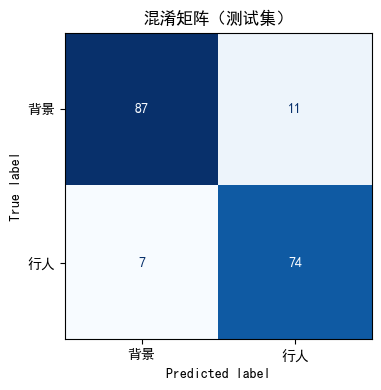

In [8]:
y_pred = svm.predict(X_test_s)

print("=" * 50)
print("分类报告")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=["背景", "行人"]))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["背景", "行人"])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title("混淆矩阵（测试集）", fontsize=12)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=100)
plt.show()

## 第七步：滑动窗口检测 + NMS

In [12]:
def sliding_window_detect(img, hog_desc, svm_model, scaler, win_w, win_h,
                          step=16,
                          scales=(1.25, 1.0, 0.75, 0.55, 0.42, 0.32),
                          score_thresh=0.5):
    """
    多尺度滑动窗口检测。

    PennFudanPed 行人高度约 100~400px，各 scale 对应原图检测框高度：
        scale=1.25 → 102px    scale=1.00 → 128px    scale=0.75 → 171px
        scale=0.55 → 233px    scale=0.42 → 305px    scale=0.32 → 400px
    返回：[(x1,y1,x2,y2,score), ...]（未经 NMS）
    """
    detections = []
    H0, W0 = img.shape[:2]

    for scale in scales:
        new_w = max(win_w, int(W0 * scale))
        new_h = max(win_h, int(H0 * scale))
        resized = cv2.resize(img, (new_w, new_h))
        gray    = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

        for y in range(0, new_h - win_h + 1, step):
            for x in range(0, new_w - win_w + 1, step):
                window = gray[y:y+win_h, x:x+win_w]
                feat   = hog_desc.compute(window).flatten().reshape(1, -1)
                feat_s = scaler.transform(feat)
                score  = svm_model.decision_function(feat_s)[0]
                if score >= score_thresh:
                    x1 = int(x / scale);          y1 = int(y / scale)
                    x2 = int((x + win_w) / scale); y2 = int((y + win_h) / scale)
                    detections.append((x1, y1, x2, y2, score))

    return detections


def nms(detections, iou_thresh=0.3):
    """Non-Maximum Suppression"""
    if not detections:
        return []
    boxes  = np.array([[d[0],d[1],d[2],d[3]] for d in detections], dtype=np.float32)
    scores = np.array([d[4] for d in detections], dtype=np.float32)
    order  = scores.argsort()[::-1]
    keep   = []
    while order.size > 0:
        i = order[0]; keep.append(i)
        xx1 = np.maximum(boxes[i,0], boxes[order[1:],0])
        yy1 = np.maximum(boxes[i,1], boxes[order[1:],1])
        xx2 = np.minimum(boxes[i,2], boxes[order[1:],2])
        yy2 = np.minimum(boxes[i,3], boxes[order[1:],3])
        inter  = np.maximum(0, xx2-xx1) * np.maximum(0, yy2-yy1)
        area_i = (boxes[i,2]-boxes[i,0]) * (boxes[i,3]-boxes[i,1])
        area_j = (boxes[order[1:],2]-boxes[order[1:],0]) * (boxes[order[1:],3]-boxes[order[1:],1])
        ious   = inter / (area_i + area_j - inter + 1e-6)
        order  = order[1:][ious < iou_thresh]
    return [detections[k] for k in keep]


# ── 尺度说明 ────────────────────────────────────────────────────
print("各 scale 对应检测框映射回原图的尺寸：")
for s in (1.25, 1.0, 0.75, 0.55, 0.42, 0.32):
    print(f"  scale={s:.2f}  →  高={int(WIN_H/s):>4d}px  宽={int(WIN_W/s):>3d}px")
print(f"\nPennFudanPed GT 框实测高度范围：280~358px")
print("修正后 scales 完整覆盖该范围 ✓")

各 scale 对应检测框映射回原图的尺寸：
  scale=1.25  →  高= 102px  宽= 51px
  scale=1.00  →  高= 128px  宽= 64px
  scale=0.75  →  高= 170px  宽= 85px
  scale=0.55  →  高= 232px  宽=116px
  scale=0.42  →  高= 304px  宽=152px
  scale=0.32  →  高= 400px  宽=200px

PennFudanPed GT 框实测高度范围：280~358px
修正后 scales 完整覆盖该范围 ✓


## 第八步：在测试图上运行检测并可视化（GT vs 预测）

检测：PennPed00091.png ... 原始=  28  NMS后=12
检测：PennPed00092.png ... 原始= 100  NMS后=26
检测：PennPed00093.png ... 原始=  38  NMS后=13
检测：PennPed00094.png ... 原始=  52  NMS后=16
检测：PennPed00095.png ... 原始=  27  NMS后=12
检测：PennPed00096.png ... 原始=  10  NMS后=6


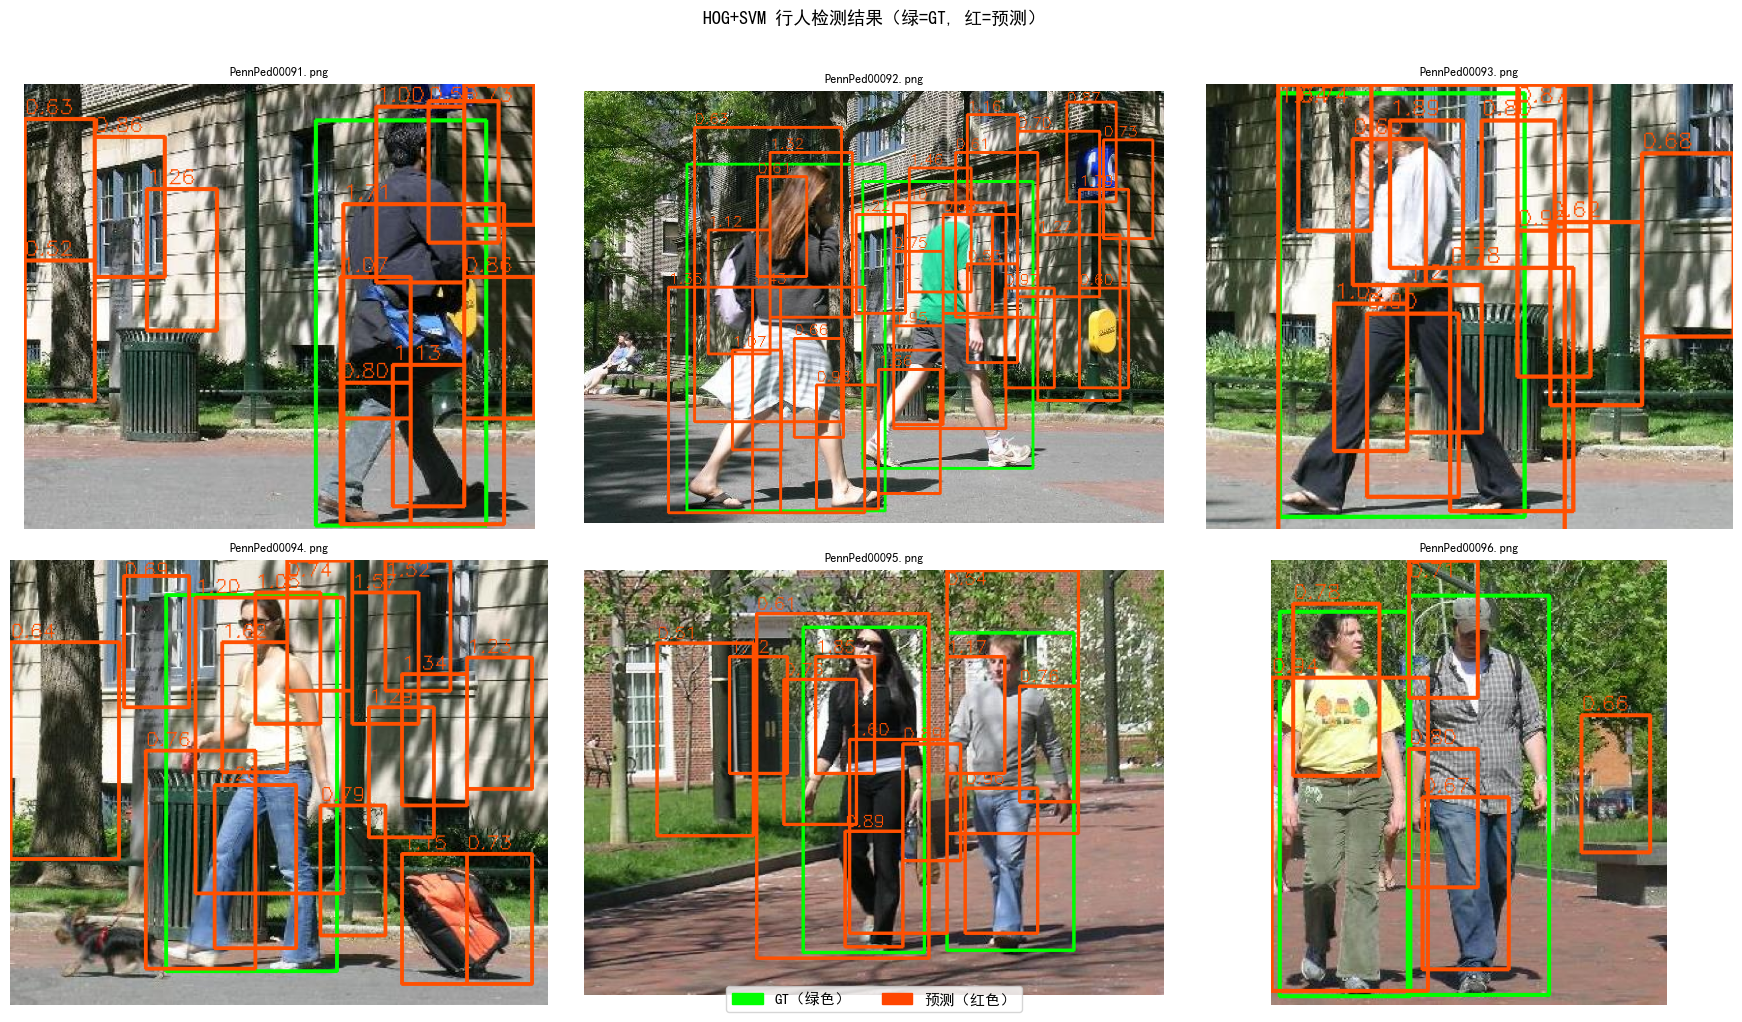

结果已保存至 detection_results.png


In [13]:
def draw_detections(img_bgr, gt_boxes, pred_boxes, title=""):
    """在图上同时画出 GT（绿色）和预测框（红色带分数）"""
    vis = img_bgr.copy()
    for (x1, y1, x2, y2) in gt_boxes:
        cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
    for (x1, y1, x2, y2, score) in pred_boxes:
        cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 80, 255), 2)
        cv2.putText(vis, f"{score:.2f}", (x1, max(y1-4, 12)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 80, 255), 1)
    return vis


# 取后 6 张作为测试图
all_img_paths  = sorted(annotation_map.keys())
test_img_paths = all_img_paths[-6:]

# ── 修正后的 scales，覆盖 PennFudanPed 实际行人高度 280~358px ──
DETECT_SCALES = (1.25, 1.0, 0.75, 0.55, 0.42, 0.32)
SCORE_THRESH  = 0.5

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
legend_gt   = mpatches.Patch(color='lime',      label='GT（绿色）')
legend_pred = mpatches.Patch(color='orangered', label='预测（红色）')

for ax, img_path in zip(axes, test_img_paths):
    img = cv2.imread(img_path)
    gt  = annotation_map[img_path]

    print(f"检测：{Path(img_path).name} ...", end=" ", flush=True)
    raw_dets   = sliding_window_detect(img, hog, svm, scaler, WIN_W, WIN_H,
                                       step=16, scales=DETECT_SCALES,
                                       score_thresh=SCORE_THRESH)
    final_dets = nms(raw_dets, iou_thresh=0.3)
    print(f"原始={len(raw_dets):>4d}  NMS后={len(final_dets)}")

    vis = draw_detections(img, gt, final_dets)
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.set_title(Path(img_path).name, fontsize=9)
    ax.axis('off')

fig.legend(handles=[legend_gt, legend_pred], loc='lower center',
           ncol=2, fontsize=11, bbox_to_anchor=(0.5, 0))
plt.suptitle("HOG+SVM 行人检测结果（绿=GT, 红=预测）", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("detection_results.png", dpi=100, bbox_inches='tight')
plt.show()
print("结果已保存至 detection_results.png")

## 第九步：简单精度评估（Precision / Recall @ IoU≥0.5）

检测评估（IoU >= 0.5，score_thresh=0.5）

图片                             GT  Pred   TP   FP   FN
-------------------------------------------------------
  PennPed00091.png              1    12    1   11    0
  PennPed00092.png              2    26    2   24    0
  PennPed00093.png              1    13    1   12    0
  PennPed00094.png              1    16    1   15    0
  PennPed00095.png              2    12    2   10    0
  PennPed00096.png              2     6    1    5    1
-------------------------------------------------------
  汇总                            1     9    8   77    1

  Precision : 0.0941
  Recall    : 0.8889
  F1-Score  : 0.1702


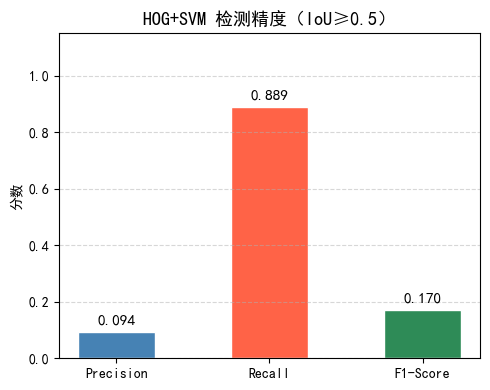

精度柱状图已保存至 pr_bar.png


In [14]:
def box_iou(boxA, boxB):
    """计算两个框 (x1,y1,x2,y2) 的 IoU"""
    xA = max(boxA[0], boxB[0]);  yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2]);  yB = min(boxA[3], boxB[3])
    inter = max(0, xB - xA) * max(0, yB - yA)
    if inter == 0:
        return 0.0
    areaA = (boxA[2]-boxA[0]) * (boxA[3]-boxA[1])
    areaB = (boxB[2]-boxB[0]) * (boxB[3]-boxB[1])
    return inter / (areaA + areaB - inter)


def evaluate_detection_set(img_paths, ann_map, hog_desc, svm_model, scaler,
                            win_w, win_h, step=16,
                            scales=(1.25, 1.0, 0.75, 0.55, 0.42, 0.32),
                            score_thresh=0.5, iou_thresh=0.5):
    """
    在给定图片列表上运行检测，统计 TP / FP / FN，计算 Precision / Recall / F1。
    匹配规则：预测框与 GT 框 IoU >= iou_thresh 则视为 TP，否则 FP；
             未被匹配到的 GT 框计为 FN。
    """
    total_tp = total_fp = total_fn = 0
    per_img  = []

    for img_path in img_paths:
        img      = cv2.imread(img_path)
        gt_boxes = ann_map[img_path]

        raw   = sliding_window_detect(img, hog_desc, svm_model, scaler,
                                      win_w, win_h, step=step,
                                      scales=scales, score_thresh=score_thresh)
        preds = nms(raw, iou_thresh=0.3)

        matched_gt = set()
        tp = fp = 0
        for (px1, py1, px2, py2, _) in preds:
            best_iou, best_gi = 0.0, -1
            for gi, (gx1, gy1, gx2, gy2) in enumerate(gt_boxes):
                if gi in matched_gt:
                    continue
                cur = box_iou((px1,py1,px2,py2), (gx1,gy1,gx2,gy2))
                if cur > best_iou:
                    best_iou, best_gi = cur, gi
            if best_iou >= iou_thresh:
                matched_gt.add(best_gi); tp += 1
            else:
                fp += 1

        fn = len(gt_boxes) - len(matched_gt)
        per_img.append((Path(img_path).name, tp, fp, fn, len(gt_boxes), len(preds)))
        total_tp += tp;  total_fp += fp;  total_fn += fn

    prec = total_tp / (total_tp + total_fp) if (total_tp + total_fp) else 0.0
    rec  = total_tp / (total_tp + total_fn) if (total_tp + total_fn) else 0.0
    f1   = 2*prec*rec / (prec+rec)          if (prec+rec)           else 0.0
    return prec, rec, f1, total_tp, total_fp, total_fn, per_img


# ── 评估（使用与步骤8相同的修正 scales）────────────────────────
print("=" * 60)
print("检测评估（IoU >= 0.5，score_thresh=0.5）")
print("=" * 60)

prec, rec, f1, tp, fp, fn, per_img = evaluate_detection_set(
    test_img_paths, annotation_map, hog, svm, scaler,
    WIN_W, WIN_H, step=16,
    scales=DETECT_SCALES,          # ← 使用步骤8中定义的修正 scales
    score_thresh=SCORE_THRESH,
    iou_thresh=0.5
)

# ── 逐图明细 ─────────────────────────────────────────────────
print(f"\n{'图片':<28} {'GT':>4} {'Pred':>5} {'TP':>4} {'FP':>4} {'FN':>4}")
print("-" * 55)
for name, t, f_p, f_n, n_gt, n_pred in per_img:
    print(f"  {name:<26} {n_gt:>4} {n_pred:>5} {t:>4} {f_p:>4} {f_n:>4}")
print("-" * 55)
print(f"  {'汇总':<26} {sum(r[3] for r in per_img):>4} "
      f"{sum(r[4] for r in per_img):>5} {tp:>4} {fp:>4} {fn:>4}")

print(f"\n  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")

# ── 柱状图 ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['Precision', 'Recall', 'F1-Score'],
              [prec, rec, f1],
              color=['steelblue', 'tomato', 'seagreen'],
              edgecolor='white', width=0.5)
for bar, val in zip(bars, [prec, rec, f1]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_title('HOG+SVM 检测精度（IoU≥0.5）', fontsize=13)
ax.set_ylabel('分数')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("pr_bar.png", dpi=100)
plt.show()
print("精度柱状图已保存至 pr_bar.png")